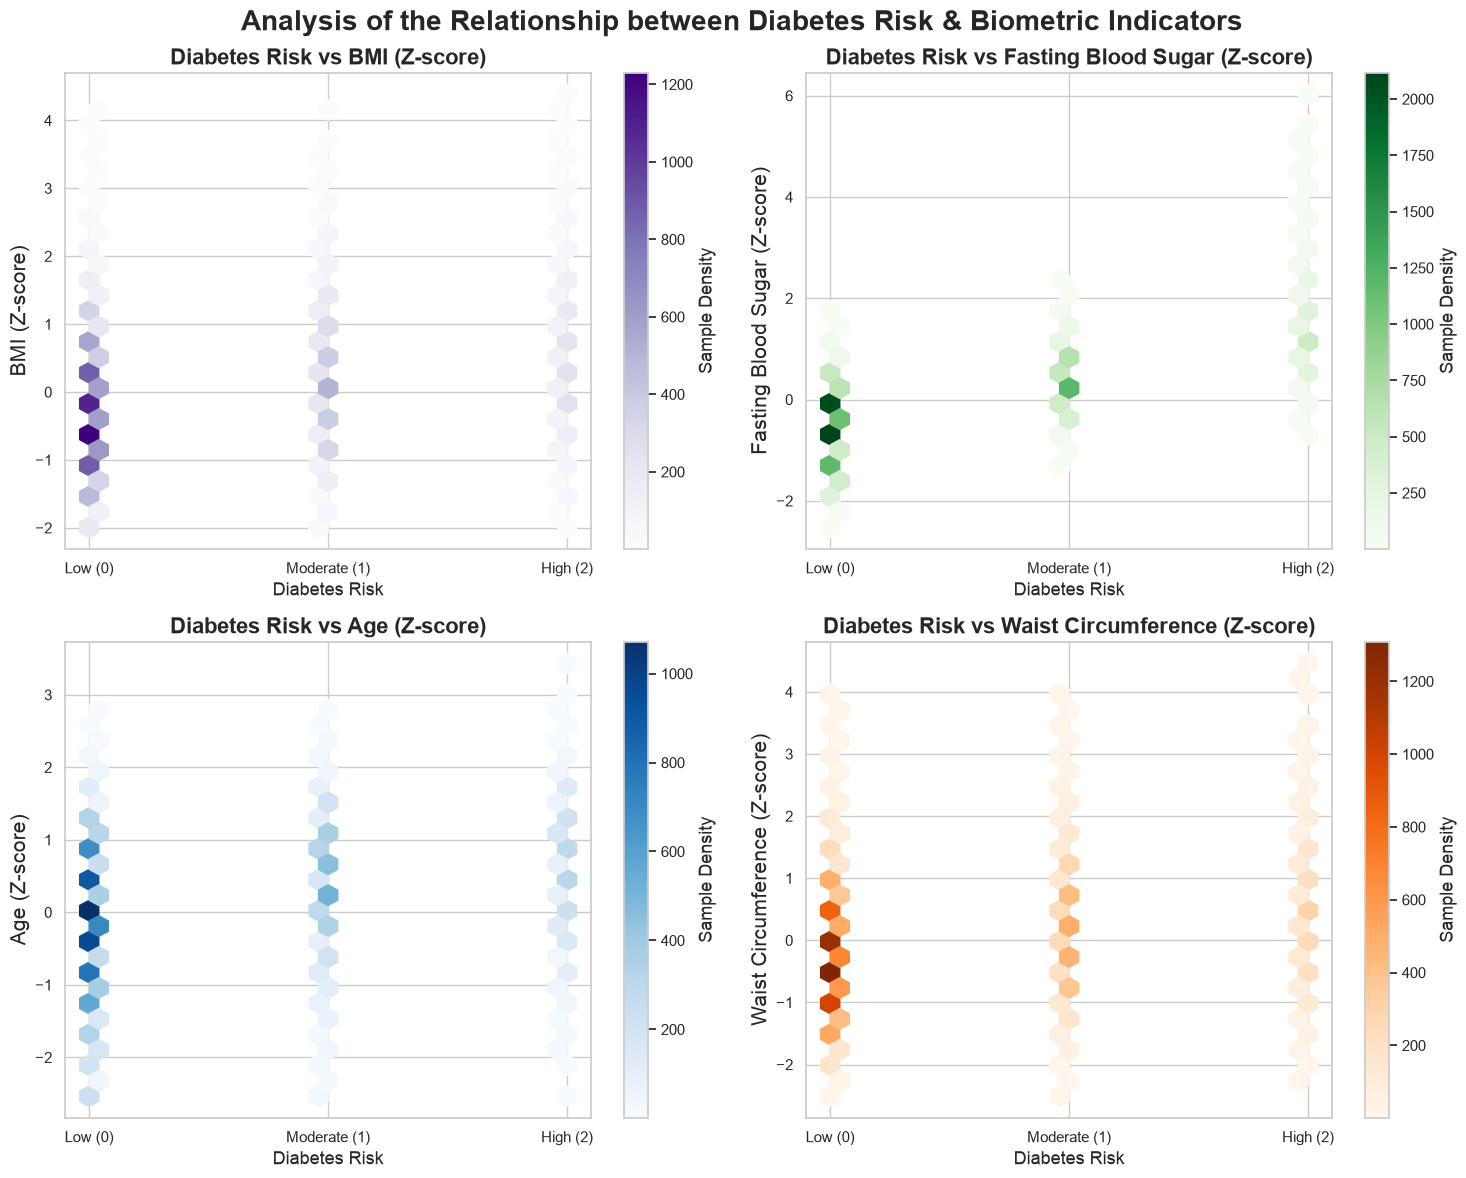

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler

df = pd.read_csv('02_data-cleaned.csv')

# Standardization 
# convert 4 variables into Z-score (Mean = 0, Std = 1)
features = ['bmi', 'fasting_blood_sugar', 'age', 'waist_circumference_cm']
scaler = StandardScaler()
df_scaled = df.copy()
df_scaled[features] = scaler.fit_transform(df[features])

fig, axes = plt.subplots(2, 2, figsize=(15, 12))
plt.subplots_adjust(hspace=0.3, wspace=0.25)
sns.set_theme(style="whitegrid")

# Cấu hình từng đồ thị: (tên_cột, nhãn_hiển_thị, trục_ax, bảng_màu)
plot_configs = [
    ('bmi', 'BMI (Z-score)', axes[0, 0], 'Purples'),
    ('fasting_blood_sugar', 'Fasting Blood Sugar (Z-score)', axes[0, 1], 'Greens'),
    ('age', 'Age (Z-score)', axes[1, 0], 'Blues'),
    ('waist_circumference_cm', 'Waist Circumference (Z-score)', axes[1, 1], 'Oranges')
]

#hexin
for col, label, ax, cmap in plot_configs:
    hb = ax.hexbin(
        df_scaled['diabetes_risk'], 
        df_scaled[col], 
        gridsize=25,       # Số lượng ô lục giác chia trên trục
        cmap=cmap,         # Bảng màu thể hiện mật độ
        mincnt=1           # Ẩn các ô không có điểm dữ liệu nào
    )
    ax.set_title(f'Diabetes Risk vs {label}', fontsize=16, fontweight='bold')
    ax.set_xlabel('Diabetes Risk', fontsize=13)
    ax.set_ylabel(label, fontsize=15)
    ax.set_xticks([0, 1, 2])
    ax.set_xticklabels(['Low (0)', 'Moderate (1)', 'High (2)'])
    
    #colorbar
    cb = fig.colorbar(hb, ax=ax)
    cb.set_label('Sample Density', fontsize=13)

plt.suptitle('Analysis of the Relationship between Diabetes Risk & Biometric Indicators', 
             fontsize=20, fontweight='bold', y=0.98)
plt.tight_layout()
plt.show()